# Figure 3 LFP event-front compilation

Paper-ready Figure 3 draft from cached stim-removal-null HD-MEA LFP excitability-front results. This notebook is read-only with respect to raw LFP processing: it loads existing wavefront HDF5 caches and composes the figure panels from derived results.

In [1]:
%matplotlib inline

import ast
import json
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import phase_waves
from phase_waves import (
    bandpass_downsample,
    extract_phasors,
    fit_k_phasor_plane,
    inspect_file,
    load_chunk,
    make_k_grid,
    read_wavefront_cache,
)
from ephax.metrics.burst import (
    assign_max_population_ifr_burst_anchors,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
)
from ephax.prep import Recording
from ephax.plotting import (
    PAPER_COLORS,
    apply_paper_style,
    compose_figure,
    export_figure,
    figure,
    panel,
)
from ephax.plotting.style import LINE_WIDTHS, FONT_SIZES

apply_paper_style()
plt.rcParams["figure.dpi"] = 170
np.random.seed(0)

/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configuration and cache

In [2]:
DIV = 12
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
EXAMPLE_WELL = 0
CACHE_PROFILE = "confirm"
LFP_SOURCE = "stim_removal_null_lfp"
BAND_LABEL = "30-50 Hz"
FS_DS = 500.0
SAVE_FIGURE = True
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 0
NULL_CORRECTION_ENABLED = True
NULL_CORRECTION_FORCE_RECOMPUTE = False
NULL_CORRECTION_REPS = 30
NULL_CORRECTION_SEED = 1
NULL_CORRECTION_TYPES = ["coordinate_shuffle", "arrival_time_shuffle"]
NULL_CORRECTION_MAX_EVENTS_PER_WELL = 25
NULL_FRONT_RADIUS_MM = 0.30
NULL_FRONT_MIN_NEIGHBORS = 8
NULL_FRONT_MAX_RADIUS_MM = 0.45
NULL_FRONT_MAX_NEIGHBORS = 24
NULL_FRONT_MIN_GEOMETRY_RATIO = 0.10
NULL_FRONT_MATCH_MAX_MS = 8.0
NULL_FRONT_MAX_RESIDUAL_MS = 4.0
NULL_FRONT_MIN_ARRIVAL_SPAN_MS = 1.0
NULL_FRONT_MIN_DISTANCE_SPAN_MM = 0.20
NULL_FRONT_MAX_SPEED_MM_PER_S = 500.0
SPEED_PANEL_MODE = "null_corrected"  # "null_corrected" or "all_qc_valid"
LFP_DIAGNOSTIC_PAD_S = 0.05
LFP_FILTER_CONTEXT_PAD_S = 0.25
TRACE_EXAMPLE_CHANNELS = 30
TRACE_EXAMPLE_GAIN = 8.0
SNAPSHOT_HEX_GRIDSIZE = 35
SNAPSHOT_HEX_MIN_VECTOR_COUNT = 3
SNAPSHOT_VECTOR_SCALE_MS = 2.2
SNAPSHOT_VECTOR_MAX_MM = 0.20
PHASE_COH_FREQ_LOW_HZ = 4.0
PHASE_COH_FREQ_HIGH_HZ = 180.0
PHASE_COH_N_BANDS = 28
PHASE_COH_REL_BANDWIDTH = 0.18
PHASE_COH_USE_ALL_CHANNELS = True
PHASE_COH_MAX_CHANNELS = None
TRACE_EXAMPLE_EVENT_IDX = None  # None selects the well-0 event with most valid local fits
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

STIM_REMOVAL_NULL_LFP_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull") / f"DIV {int(DIV)}" / "data.raw.h5"
WAVE_CACHE_DIR = repo_root / "outputs" / "lfp_waves"
OUTPUT_DIR = repo_root / "outputs" / "figure3_lfp_event_front"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_NOTE = "Cached confirm burst-front screen, 30-50 Hz, 500 Hz"
FIGURE3_PRIMARY_COLOR = PAPER_COLORS["ephaptic_axonal"]
FIGURE3_PRIMARY_LIGHT = "#ead6f6"
FIGURE3_ACCENT_COLOR = PAPER_COLORS["highlight"]
FIGURE3_BURST_COLOR = PAPER_COLORS["burst"]


def wavefront_cache_path(well):
    well = int(well)
    return WAVE_CACHE_DIR / (
        f"wavefront_{LFP_SOURCE}_{CACHE_PROFILE}_well{well}_DIV{DIV}_data{well:04d}_burst_"
        "30-50Hz_fs500_lambda0.5-10_radial1.h5"
    )


cache_paths = {well: wavefront_cache_path(well) for well in AGGREGATE_WELLS}
missing = [str(path) for path in cache_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Figure 3 wavefront caches:\n" + "\n".join(missing))

for well, path in cache_paths.items():
    with h5py.File(path, "r") as h5:
        if not bool(h5.attrs.get("complete", False)):
            raise ValueError(f"Wavefront cache is not marked complete for well {well}: {path}")
        required_groups = {"wavefront_calibration", "wavefront_events", "wavefront_local"}
        if not required_groups.issubset(h5.keys()):
            raise ValueError(f"Wavefront cache {path} is missing groups: {required_groups - set(h5.keys())}")

cache_paths


{0: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_permissive_well0_DIV12_data0000_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 1: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_permissive_well1_DIV12_data0001_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 2: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_permissive_well2_DIV12_data0002_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 3: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_permissive_well3_DIV12_data0003_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 4: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_permissive_well4_DIV12_data0004_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 5: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs

## Derived panel-ready tables

In [3]:
def _as_dataframe(payload, *, well, path, group_name):
    columns = {}
    for key, value in payload.items():
        if isinstance(value, np.ndarray) and value.ndim > 0:
            columns[key] = value
    if not columns:
        return pd.DataFrame()
    lengths = {key: len(value) for key, value in columns.items()}
    first_len = next(iter(lengths.values()))
    keep = {key: value for key, value in columns.items() if len(value) == first_len}
    frame = pd.DataFrame(keep)
    frame.insert(0, "well", int(well))
    frame.insert(1, "cache_path", str(path))
    frame.insert(2, "group_name", group_name)
    return frame


def _calibration_frames(payload, *, well, path):
    attrs = {key: value for key, value in payload.items() if not isinstance(value, np.ndarray)}
    config = json.loads(attrs.get("config", "{}")) if attrs.get("config") else {}
    centers = np.asarray(payload["phase_bin_centers_rad"], dtype=float)
    rel_prob = np.asarray(payload["relative_spike_probability"], dtype=float)
    occupancy = np.asarray(payload["occupancy_counts"], dtype=float)
    spike_counts = np.asarray(payload["spike_phase_counts"], dtype=float)
    curve = pd.DataFrame({
        "well": int(well),
        "cache_path": str(path),
        "phase_rad": centers,
        "relative_spike_probability": rel_prob,
        "occupancy_counts": occupancy,
        "spike_phase_counts": spike_counts,
    })
    summary = {
        "well": int(well),
        "cache_path": str(path),
        "theta_excitable_rad": float(attrs.get("theta_excitable_rad", np.nan)),
        "n_spikes_sampled": int(attrs.get("n_spikes_sampled", 0)),
        "calibration_theta_resultant": float(attrs.get("calibration_theta_resultant", np.nan)),
        "calibration_theta_circular_std_rad": float(attrs.get("calibration_theta_circular_std_rad", np.nan)),
        "calibration_stable": bool(attrs.get("calibration_stable", False)),
        "calibration_interval_count": int(attrs.get("calibration_interval_count", 0)),
        "config": config,
    }
    return curve, summary


def load_all_wavefront_caches(cache_paths):
    calibration_curves = []
    calibration_summaries = []
    events = []
    locals_ = []
    for well, path in cache_paths.items():
        cache = read_wavefront_cache(path)
        curve, summary = _calibration_frames(cache["wavefront_calibration"], well=well, path=path)
        calibration_curves.append(curve)
        calibration_summaries.append(summary)
        event = _as_dataframe(cache["wavefront_events"], well=well, path=path, group_name="wavefront_events")
        local = _as_dataframe(cache["wavefront_local"], well=well, path=path, group_name="wavefront_local")
        events.append(event)
        locals_.append(local)
    calibration_df = pd.concat(calibration_curves, ignore_index=True)
    calibration_summary_df = pd.DataFrame(calibration_summaries)
    event_df = pd.concat(events, ignore_index=True)
    local_df = pd.concat(locals_, ignore_index=True)
    return calibration_df, calibration_summary_df, event_df, local_df


calibration_df, calibration_summary_df, event_df, local_df = load_all_wavefront_caches(cache_paths)

required_local = {"well", "event_idx", "valid", "speed_mm_per_s"}
missing_local = required_local - set(local_df.columns)
if missing_local:
    raise ValueError(f"local_df is missing required columns: {missing_local}")
required_cal = {"well", "phase_rad", "relative_spike_probability"}
missing_cal = required_cal - set(calibration_df.columns)
if missing_cal:
    raise ValueError(f"calibration_df is missing required columns: {missing_cal}")

local_df["valid"] = local_df["valid"].astype(bool)
if "speed_censored" in local_df.columns:
    local_df["speed_censored"] = local_df["speed_censored"].astype(bool)
else:
    local_df["speed_censored"] = False
if "front_valid" in event_df.columns:
    event_df["front_valid"] = event_df["front_valid"].astype(bool)

valid_local_df = local_df.loc[local_df["valid"] & np.isfinite(local_df["speed_mm_per_s"])].copy()
event_speed_df = (
    valid_local_df.groupby(["well", "event_idx"], as_index=False)
    .agg(
        median_speed_mm_per_s=("speed_mm_per_s", "median"),
        mean_speed_mm_per_s=("speed_mm_per_s", "mean"),
        n_valid_local_fits=("speed_mm_per_s", "size"),
    )
)
well_summary_df = (
    event_speed_df.groupby("well", as_index=False)
    .agg(
        median_event_speed_mm_per_s=("median_speed_mm_per_s", "median"),
        mean_event_speed_mm_per_s=("median_speed_mm_per_s", "mean"),
        n_events=("event_idx", "nunique"),
        total_valid_local_fits=("n_valid_local_fits", "sum"),
    )
)

missing_event_wells = sorted(set(AGGREGATE_WELLS) - set(event_speed_df["well"].unique()))
if missing_event_wells:
    raise ValueError(f"No valid event speed medians for wells: {missing_event_wells}")

print(f"Loaded {len(calibration_summary_df)} wells, {len(event_df)} events, {len(valid_local_df)} QC-valid local fits.")
print(f"Event medians: {len(event_speed_df)} events across {event_speed_df['well'].nunique()} wells.")
display(well_summary_df.round(3))

Loaded 6 wells, 90 events, 46098 QC-valid local fits.
Event medians: 90 events across 6 wells.


,well,median_event_speed_mm_per_s,mean_event_speed_mm_per_s,n_events,total_valid_local_fits
0,0,73.568,73.742,15,7354
1,1,90.336,92.337,15,8197
2,2,66.801,68.425,15,7443
3,3,73.572,74.581,15,7916
4,4,70.487,71.525,15,7858
5,5,74.459,74.586,15,7330


## Example event gamma traces


In [4]:
def dataset_for_well(well):
    return f"data{int(well):04d}"


def load_data_store_spikes(file_path, dataset, *, min_amp=0.0):
    raw_path, rec_group_path = phase_waves._resolve_dataset_paths(dataset, file_path)
    with h5py.File(file_path, "r") as h5:
        rec_group = h5[rec_group_path]
        settings = rec_group["settings"]
        mapping_obj = settings["mapping"]
        if getattr(mapping_obj, "dtype", None) is not None and mapping_obj.dtype.fields is not None:
            mapping_arr = mapping_obj[:]
            layout = {name: np.asarray(mapping_arr[name]) for name in ("channel", "electrode", "x", "y")}
        else:
            layout = {name: np.asarray(mapping_obj[name])[:] for name in ("channel", "electrode", "x", "y")}
        sf = float(settings["sampling"][0])
        spikes_arr = rec_group["spikes"][:]
        frame_nos = h5[raw_path].parent.get("frame_nos")
        first_frame = int(frame_nos[0]) if frame_nos is not None and frame_nos.shape[0] else int(np.nanmin(spikes_arr["frameno"])) if spikes_arr.size else 0
        spikes_data = {
            "time": (np.asarray(spikes_arr["frameno"], dtype=float) - first_frame) / sf,
            "channel": np.asarray(spikes_arr["channel"]),
            "amplitude": np.asarray(spikes_arr["amplitude"]),
        }
        channel_to_electrode = {int(ch): int(el) for ch, el in zip(layout["channel"], layout["electrode"])}
        spikes_data["electrode"] = np.asarray([channel_to_electrode.get(int(ch), -1) for ch in spikes_data["channel"]])
        keep = (spikes_data["electrode"] >= 0) & (spikes_data["time"] >= 0) & (np.abs(spikes_data["amplitude"]) >= float(min_amp))
        spikes_data = {key: np.asarray(value)[keep] for key, value in spikes_data.items()}
    return spikes_data, layout, sf


def detect_example_well_bursts(well):
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    spikes, layout, sf = load_data_store_spikes(STIM_REMOVAL_NULL_LFP_FILE, dataset, min_amp=MIN_AMP)
    stop_s = min(info["raw_shape"][1] / info["fs_raw"], float(np.nanmax(spikes["time"])) if len(spikes["time"]) else np.inf)
    recording = Recording(spikes=spikes, layout=layout, start_time=0.0, end_time=stop_s, sf=float(sf))
    refs = recording.refs_top(start=TOP_START, stop=TOP_STOP)
    population = build_population_ifr(recording, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    high_epochs, _ = detect_high_activity_epochs(
        population.time_grid, population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    highres = build_highres_traces(recording, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    network = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
    bursts = detect_participation_burst_epochs(
        network, high_epochs,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    return assign_max_population_ifr_burst_anchors(highres, bursts).sort_values("anchor_time_s").reset_index(drop=True), info


def select_trace_event(event_speed_df, *, well, explicit_event_idx=None):
    well_events = event_speed_df.loc[event_speed_df["well"] == int(well)].copy()
    if explicit_event_idx is not None:
        selected = well_events.loc[well_events["event_idx"] == int(explicit_event_idx)]
        if selected.empty:
            raise ValueError(f"TRACE_EXAMPLE_EVENT_IDX={explicit_event_idx} not present for well {well}")
        return selected.iloc[0]
    return well_events.sort_values(["n_valid_local_fits", "median_speed_mm_per_s"], ascending=False).iloc[0]


def load_lfp_trace_example(well, event_idx, anchor_time_s, *, n_channels=28):
    bursts, info = detect_example_well_bursts(well)
    matches = bursts.loc[np.isclose(bursts["anchor_time_s"].to_numpy(float), float(anchor_time_s), atol=1e-3)]
    if matches.empty and "event_idx" in bursts.columns:
        matches = bursts.loc[bursts["event_idx"].astype(int) == int(event_idx)]
    if matches.empty:
        nearest_idx = int(np.argmin(np.abs(bursts["anchor_time_s"].to_numpy(float) - float(anchor_time_s))))
        matches = bursts.iloc[[nearest_idx]]
    burst = matches.iloc[0]
    core = (float(burst["start_time_s"]), float(burst["end_time_s"]))
    recording_stop_s = info["raw_shape"][1] / info["fs_raw"]
    display_interval = (
        max(0.0, core[0] - LFP_DIAGNOSTIC_PAD_S),
        min(recording_stop_s, core[1] + LFP_DIAGNOSTIC_PAD_S),
    )
    filter_interval = (
        max(0.0, core[0] - LFP_FILTER_CONTEXT_PAD_S),
        min(recording_stop_s, core[1] + LFP_FILTER_CONTEXT_PAD_S),
    )
    dataset = dataset_for_well(well)
    start_frame = int(round(filter_interval[0] * info["fs_raw"]))
    n_frames = max(1, int(round((filter_interval[1] - filter_interval[0]) * info["fs_raw"])))
    raw_full, coords_mm, fs_raw, mapping = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    band_full = bandpass_downsample(raw_full, fs_raw, 30.0, 50.0, FS_DS, max_channels_per_block=128)
    t_raw_full = filter_interval[0] + np.arange(raw_full.shape[0]) / fs_raw
    t_band_full = filter_interval[0] + np.arange(band_full.shape[0]) / FS_DS
    u, amplitude = extract_phasors(band_full)
    anchor_idx = int(np.argmin(np.abs(t_band_full - float(anchor_time_s))))
    phase_anchor = np.angle(u[anchor_idx])
    amp_anchor = amplitude[anchor_idx]
    eligible = np.flatnonzero(np.isfinite(phase_anchor) & np.isfinite(amp_anchor))
    order = eligible[np.argsort(phase_anchor[eligible])]
    if order.size > int(n_channels):
        pick = np.round(np.linspace(0, order.size - 1, int(n_channels))).astype(int)
        channels = order[pick]
    else:
        channels = order
    channels = channels[np.argsort(phase_anchor[channels])]
    raw_display = (t_raw_full >= display_interval[0]) & (t_raw_full <= display_interval[1])
    band_display = (t_band_full >= display_interval[0]) & (t_band_full <= display_interval[1])
    return {
        "well": int(well),
        "event_idx": int(event_idx),
        "anchor_time_s": float(anchor_time_s),
        "core_interval_s": core,
        "display_interval_s": display_interval,
        "filter_interval_s": filter_interval,
        "raw": raw_full[raw_display][:, channels],
        "band": band_full[band_display][:, channels],
        "t_raw": t_raw_full[raw_display],
        "t_band": t_band_full[band_display],
        "phase_anchor": phase_anchor[channels],
        "amplitude_anchor": amp_anchor[channels],
        "snapshot_phase_anchor": phase_anchor,
        "snapshot_amplitude_anchor": amp_anchor,
        "coords_mm": np.asarray(coords_mm, dtype=float),
        "snapshot_channels": np.asarray(mapping["channel"]),
        "snapshot_electrodes": np.asarray(mapping["electrode"]),
        "channels": np.asarray(mapping["channel"])[channels],
        "electrodes": np.asarray(mapping["electrode"])[channels],
    }


trace_event_row = select_trace_event(event_speed_df, well=EXAMPLE_WELL, explicit_event_idx=TRACE_EXAMPLE_EVENT_IDX)
_trace_event_idx = int(trace_event_row["event_idx"])
_trace_anchor_row = event_df.loc[
    (event_df["well"].astype(int) == int(EXAMPLE_WELL))
    & (event_df["event_idx"].astype(int) == _trace_event_idx)
]
if _trace_anchor_row.empty:
    raise ValueError(f"No cached event row found for well {EXAMPLE_WELL}, event {_trace_event_idx}")
example_trace_data = load_lfp_trace_example(
    EXAMPLE_WELL,
    _trace_event_idx,
    float(_trace_anchor_row["anchor_time_s"].iloc[0]),
    n_channels=TRACE_EXAMPLE_CHANNELS,
)
print(
    f"Trace example: well {example_trace_data['well']}, event {example_trace_data['event_idx']}, "
    f"burst {example_trace_data['core_interval_s'][0]:.3f}-{example_trace_data['core_interval_s'][1]:.3f}s, "
    f"pad {LFP_DIAGNOSTIC_PAD_S:g}s"
)

Trace example: well 0, event 99, burst 322.300-322.400s, pad 0.05s


## Standalone phase-coherence diagnostic


Phase-coherence heatmap: 1020 channels, 28 log-spaced bands, 322.250-322.450s


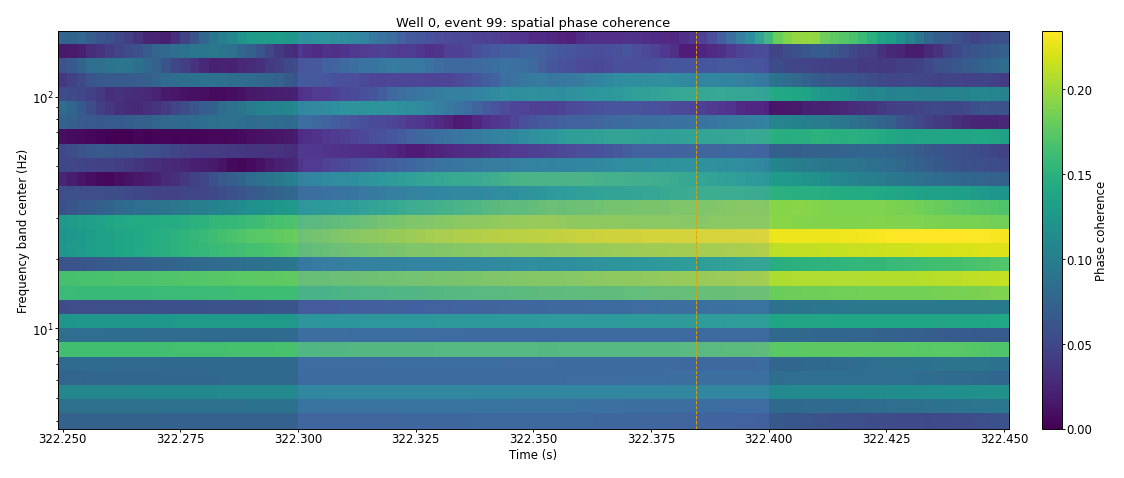

In [5]:
def make_log_frequency_bands(low_hz, high_hz, n_bands, rel_bandwidth, *, fs_ds=500.0):
    centers = np.geomspace(float(low_hz), float(high_hz), int(n_bands))
    nyquist = 0.5 * float(fs_ds)
    bands = []
    for center in centers:
        half_width = 0.5 * float(rel_bandwidth) * center
        band_low = max(0.25, center - half_width)
        band_high = min(0.98 * nyquist, center + half_width)
        if band_high <= band_low:
            continue
        bands.append((float(center), float(band_low), float(band_high)))
    return pd.DataFrame(bands, columns=["center_hz", "low_hz", "high_hz"])


def compute_example_phase_coherence_heatmap(trace, *, use_all_channels=True, max_channels=None):
    well = int(trace["well"])
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    filter_interval = tuple(float(v) for v in trace["filter_interval_s"])
    display_interval = tuple(float(v) for v in trace["display_interval_s"])
    start_frame = int(round(filter_interval[0] * info["fs_raw"]))
    n_frames = max(1, int(round((filter_interval[1] - filter_interval[0]) * info["fs_raw"])))
    raw_full, coords_mm, fs_raw, mapping = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    channel_ids = np.asarray(mapping["channel"])
    if use_all_channels:
        channel_idx = np.arange(raw_full.shape[1])
    else:
        selected = np.asarray(trace["channels"])
        channel_idx = np.flatnonzero(np.isin(channel_ids, selected))
    if max_channels is not None and channel_idx.size > int(max_channels):
        pick = np.round(np.linspace(0, channel_idx.size - 1, int(max_channels))).astype(int)
        channel_idx = channel_idx[pick]
    if channel_idx.size == 0:
        raise ValueError("No channels available for phase-coherence heatmap")
    raw_selected = raw_full[:, channel_idx]
    bands = make_log_frequency_bands(
        PHASE_COH_FREQ_LOW_HZ,
        PHASE_COH_FREQ_HIGH_HZ,
        PHASE_COH_N_BANDS,
        PHASE_COH_REL_BANDWIDTH,
        fs_ds=FS_DS,
    )
    coherence_rows = []
    t_ds_full = None
    display_mask = None
    for _, row in bands.iterrows():
        band_ds = bandpass_downsample(
            raw_selected,
            fs_raw,
            float(row["low_hz"]),
            float(row["high_hz"]),
            FS_DS,
            max_channels_per_block=128,
        )
        if t_ds_full is None:
            t_ds_full = filter_interval[0] + np.arange(band_ds.shape[0]) / FS_DS
            display_mask = (t_ds_full >= display_interval[0]) & (t_ds_full <= display_interval[1])
        u, _ = extract_phasors(band_ds)
        coherence = np.abs(np.nanmean(u, axis=1))
        coherence_rows.append(coherence[display_mask])
    coherence = np.vstack(coherence_rows)
    return {
        "well": well,
        "event_idx": int(trace["event_idx"]),
        "anchor_time_s": float(trace["anchor_time_s"]),
        "core_interval_s": tuple(float(v) for v in trace["core_interval_s"]),
        "display_interval_s": display_interval,
        "filter_interval_s": filter_interval,
        "time_s": t_ds_full[display_mask],
        "bands": bands,
        "coherence": coherence,
        "n_channels": int(channel_idx.size),
    }


def draw_phase_coherence_heatmap(coherence_data, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    time_s = np.asarray(coherence_data["time_s"], dtype=float)
    bands = coherence_data["bands"]
    centers = bands["center_hz"].to_numpy(float)
    coherence = np.asarray(coherence_data["coherence"], dtype=float)
    vmax = float(np.nanmax(coherence)) if np.any(np.isfinite(coherence)) else 1.0
    vmax = max(vmax, np.finfo(float).eps)
    mesh = ax.pcolormesh(time_s, centers, coherence, shading="auto", cmap="viridis", vmin=0.0, vmax=vmax)
    core = coherence_data["core_interval_s"]
    ax.axvspan(core[0], core[1], color=FIGURE3_PRIMARY_COLOR, alpha=0.16, linewidth=0)
    ax.axvline(coherence_data["anchor_time_s"], color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["base"], ls="--")
    ax.set_yscale("log")
    ax.set(
        xlabel="Time (s)",
        ylabel="Frequency band center (Hz)",
        title=f"Well {coherence_data['well']}, event {coherence_data['event_idx']}: spatial phase coherence",
    )
    cbar = ax.figure.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label("Phase coherence")
    return {"mappable": mesh, "colorbar": cbar}


phase_coherence_data = compute_example_phase_coherence_heatmap(
    example_trace_data,
    use_all_channels=PHASE_COH_USE_ALL_CHANNELS,
    max_channels=PHASE_COH_MAX_CHANNELS,
)
print(
    f"Phase-coherence heatmap: {phase_coherence_data['n_channels']} channels, "
    f"{len(phase_coherence_data['bands'])} log-spaced bands, "
    f"{phase_coherence_data['display_interval_s'][0]:.3f}-{phase_coherence_data['display_interval_s'][1]:.3f}s"
)

fig, ax = plt.subplots(figsize=(6.5, 2.7), constrained_layout=True)
draw_phase_coherence_heatmap(phase_coherence_data, ax=ax)
plt.show()


## Bootstrap summaries

In [6]:
def bootstrap_well_medians(event_speed_df, *, reps=10_000, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for well, group in event_speed_df.groupby("well"):
        values = group["median_speed_mm_per_s"].to_numpy(float)
        draws = np.empty(int(reps), dtype=float)
        for rep in range(int(reps)):
            draws[rep] = np.nanmedian(rng.choice(values, size=values.size, replace=True))
        rows.append({
            "well": int(well),
            "median_speed_mm_per_s": float(np.nanmedian(values)),
            "ci_low_mm_per_s": float(np.nanpercentile(draws, 2.5)),
            "ci_high_mm_per_s": float(np.nanpercentile(draws, 97.5)),
            "n_events": int(values.size),
            "bootstrap_samples": draws,
        })
    return pd.DataFrame(rows)


def hierarchical_bootstrap_speed(event_speed_df, *, reps=10_000, seed=0):
    rng = np.random.default_rng(seed)
    grouped = {int(well): group["median_speed_mm_per_s"].to_numpy(float) for well, group in event_speed_df.groupby("well")}
    wells = np.asarray(sorted(grouped), dtype=int)
    samples = np.empty(int(reps), dtype=float)
    for rep in range(int(reps)):
        sampled_wells = rng.choice(wells, size=wells.size, replace=True)
        well_medians = []
        for well in sampled_wells:
            values = grouped[int(well)]
            resampled = rng.choice(values, size=values.size, replace=True)
            well_medians.append(np.nanmedian(resampled))
        samples[rep] = np.nanmedian(well_medians)
    return {
        "median_mm_per_s": float(np.nanmedian(samples)),
        "ci_low_mm_per_s": float(np.nanpercentile(samples, 2.5)),
        "ci_high_mm_per_s": float(np.nanpercentile(samples, 97.5)),
        "samples": samples,
        "n_wells": int(wells.size),
        "n_events": int(len(event_speed_df)),
        "n_valid_local_fits": int(valid_local_df.shape[0]),
    }


def phase_notebook_bootstrap_speed(event_speed_df, *, reps=10_000, seed=0):
    """Match the null-corrected bootstrap convention used in phase_waves_hdmea_lfp.ipynb."""
    rng = np.random.default_rng(seed)
    grouped = {int(well): group["median_speed_mm_per_s"].to_numpy(float) for well, group in event_speed_df.groupby("well")}
    wells = np.asarray(sorted(grouped), dtype=int)
    samples = []
    for _ in range(int(reps)):
        sampled_wells = rng.choice(wells, size=wells.size, replace=True)
        sampled = []
        for well in sampled_wells:
            values = grouped[int(well)]
            values = values[np.isfinite(values)]
            if values.size:
                sampled.extend(rng.choice(values, size=values.size, replace=True))
        if sampled:
            samples.append(np.nanmedian(sampled))
    samples = np.asarray(samples, dtype=float)
    return {
        "median_mm_per_s": float(np.nanpercentile(samples, 50.0)),
        "ci_low_mm_per_s": float(np.nanpercentile(samples, 2.5)),
        "ci_high_mm_per_s": float(np.nanpercentile(samples, 97.5)),
        "samples": samples,
        "n_wells": int(wells.size),
        "n_events": int(len(event_speed_df)),
        "n_valid_local_fits": int(valid_local_df.shape[0]),
    }


well_bootstrap_df = bootstrap_well_medians(event_speed_df, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED)
hierarchical_summary = hierarchical_bootstrap_speed(event_speed_df, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED + 1)

print(
    "Hierarchical event-front speed: "
    f"{hierarchical_summary['median_mm_per_s']:.1f} mm/s "
    f"(95% CI {hierarchical_summary['ci_low_mm_per_s']:.1f}-{hierarchical_summary['ci_high_mm_per_s']:.1f})"
)
display(well_bootstrap_df.drop(columns="bootstrap_samples").round(3))


Hierarchical event-front speed: 73.1 mm/s (95% CI 69.4-82.0)


,well,median_speed_mm_per_s,ci_low_mm_per_s,ci_high_mm_per_s,n_events
0,0,73.568,69.812,77.100,15
1,1,90.336,84.921,99.297,15
2,2,66.801,64.092,72.002,15
3,3,73.572,71.886,77.544,15
4,4,70.487,67.004,75.640,15
5,5,74.459,69.944,78.785,15


### Null-corrected speed panel data

Cache-only spatial-null support thresholding for the Figure 3 speed panels. This uses cached wavefront local-arrival rows and writes a small derived CSV cache; it does not load or refilter raw LFP.


In [ ]:
def _null_cache_path():
    wells = "-".join(str(int(w)) for w in AGGREGATE_WELLS)
    null_types = "-".join(NULL_CORRECTION_TYPES)
    return OUTPUT_DIR / "tables" / (
        f"wavefront_spatial_null_{LFP_SOURCE}_{CACHE_PROFILE}_DIV{DIV}_w{wells}_"
        f"{null_types}_reps{int(NULL_CORRECTION_REPS)}_seed{int(NULL_CORRECTION_SEED)}_"
        f"cap{NULL_CORRECTION_MAX_EVENTS_PER_WELL}_span{NULL_FRONT_MIN_ARRIVAL_SPAN_MS:g}ms_"
        f"rms{NULL_FRONT_MAX_RESIDUAL_MS:g}ms_radius{NULL_FRONT_RADIUS_MM:g}mm.csv"
    )


def _event_null_fit_from_cached_local(group, rng, *, null_type):
    coords = group[["x_mm", "y_mm"]].to_numpy(float)
    arrival = group["arrival_time_s"].to_numpy(float)
    amp = group["arrival_amplitude"].to_numpy(float) if "arrival_amplitude" in group else None
    if "arrival_amplitude_threshold" in group:
        amp_threshold = group["arrival_amplitude_threshold"].to_numpy(float)
        amp_threshold = np.where(np.isfinite(amp_threshold), amp_threshold, 0.0)
    else:
        amp_threshold = 0.0
    if null_type == "coordinate_shuffle":
        coords = coords[rng.permutation(coords.shape[0])]
    elif null_type == "arrival_time_shuffle":
        arrival = arrival[rng.permutation(arrival.size)]
    else:
        raise ValueError("null_type must be 'coordinate_shuffle' or 'arrival_time_shuffle'")
    neighborhoods = phase_waves.make_local_phase_neighborhoods(
        coords,
        radius_mm=NULL_FRONT_RADIUS_MM,
        min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
        max_radius_mm=NULL_FRONT_MAX_RADIUS_MM,
        max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
        min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO,
    )
    fitted = phase_waves.fit_local_arrival_velocity(
        arrival,
        coords,
        neighborhoods,
        arrival_amplitude=amp,
        min_arrival_amplitude=amp_threshold,
        match_max_ms=NULL_FRONT_MATCH_MAX_MS,
        min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
        max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS,
        min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
        min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM,
        max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
    )
    valid = np.asarray(fitted["valid"], dtype=bool)
    speeds = np.asarray(fitted["speed_mm_per_s"], dtype=float)
    return {
        "median_speed_mm_per_s": float(np.nanmedian(speeds[valid])) if np.any(valid) else np.nan,
        "n_valid": int(np.count_nonzero(valid)),
    }


def compute_or_load_front_null_df():
    null_cache_path = _null_cache_path()
    null_cache_path.parent.mkdir(parents=True, exist_ok=True)
    if null_cache_path.exists() and not NULL_CORRECTION_FORCE_RECOMPUTE:
        print(f"Loaded cached spatial-null support table: {null_cache_path}")
        return pd.read_csv(null_cache_path)

    rng = np.random.default_rng(int(NULL_CORRECTION_SEED))
    observed = event_speed_df.rename(columns={"n_valid_local_fits": "observed_n_valid"})[
        ["well", "event_idx", "median_speed_mm_per_s", "observed_n_valid"]
    ].rename(columns={"median_speed_mm_per_s": "observed_median_speed_mm_per_s"})
    selected_parts = []
    for well, group in observed.sort_values(["well", "event_idx"]).groupby("well", sort=True):
        if NULL_CORRECTION_MAX_EVENTS_PER_WELL is None or len(group) <= int(NULL_CORRECTION_MAX_EVENTS_PER_WELL):
            selected_parts.append(group)
        else:
            pick = np.round(np.linspace(0, len(group) - 1, int(NULL_CORRECTION_MAX_EVENTS_PER_WELL))).astype(int)
            selected_parts.append(group.iloc[pick])
    selected = pd.concat(selected_parts, ignore_index=True) if selected_parts else observed.iloc[:0].copy()
    selected_keys = set(zip(selected["well"].astype(int), selected["event_idx"].astype(int)))
    grouped_events = [
        (key, group)
        for key, group in local_df.groupby(["well", "event_idx"], sort=False)
        if (int(key[0]), int(key[1])) in selected_keys
    ]
    print(
        f"Computing cache-only spatial nulls for Figure 3: {len(grouped_events)} events, "
        f"{NULL_CORRECTION_REPS} reps x {len(NULL_CORRECTION_TYPES)} null types."
    )
    rows = []
    for null_type in NULL_CORRECTION_TYPES:
        for rep in range(int(NULL_CORRECTION_REPS)):
            for (well, event_idx), group in grouped_events:
                fit = _event_null_fit_from_cached_local(group, rng, null_type=null_type)
                rows.append({
                    "null_type": null_type,
                    "null_rep": int(rep),
                    "well": int(well),
                    "event_idx": int(event_idx),
                    **fit,
                })
    front_null_df = pd.DataFrame(rows)
    front_null_df.to_csv(null_cache_path, index=False)
    print(f"Wrote spatial-null support table: {null_cache_path}")
    return front_null_df


def build_null_corrected_speed_tables():
    if not NULL_CORRECTION_ENABLED:
        return event_speed_df.copy(), well_bootstrap_df.copy(), hierarchical_summary.copy(), pd.DataFrame(), pd.DataFrame()
    front_null_df = compute_or_load_front_null_df()
    if front_null_df.empty:
        print("Spatial-null table is empty; falling back to all QC-valid event speeds.")
        return event_speed_df.copy(), well_bootstrap_df.copy(), hierarchical_summary.copy(), front_null_df, pd.DataFrame()

    support_thresholds = (
        front_null_df
        .groupby(["well", "null_type"], as_index=False)["n_valid"]
        .quantile(0.95)
        .rename(columns={"n_valid": "n_valid_q95"})
    )
    support_threshold_by_well = (
        support_thresholds
        .groupby("well", as_index=False)
        .agg(n_valid_significance_threshold=("n_valid_q95", "max"))
    )
    corrected = event_speed_df.rename(columns={"n_valid_local_fits": "n_valid"}).merge(
        support_threshold_by_well, on="well", how="left"
    )
    corrected["front_support_significant"] = corrected["n_valid"] >= corrected["n_valid_significance_threshold"]
    corrected_event_speed_df = corrected.loc[
        corrected["front_support_significant"].astype(bool)
        & np.isfinite(corrected["median_speed_mm_per_s"])
    ].copy()
    if corrected_event_speed_df.empty:
        raise ValueError("No event speeds survived the spatial-null support threshold.")
    corrected_well_bootstrap_df = bootstrap_well_medians(corrected_event_speed_df, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED + 101)
    corrected_hierarchical_summary = phase_notebook_bootstrap_speed(corrected_event_speed_df, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED + 102)
    selected_keys = set(zip(corrected_event_speed_df["well"].astype(int), corrected_event_speed_df["event_idx"].astype(int)))
    corrected_hierarchical_summary["n_valid_local_fits"] = int(
        sum(
            1 for well, event_idx in zip(valid_local_df["well"].astype(int), valid_local_df["event_idx"].astype(int))
            if (int(well), int(event_idx)) in selected_keys
        )
    )
    corrected_summary = (
        corrected.groupby("well", as_index=False)
        .agg(
            n_events=("event_idx", "nunique"),
            n_front_significant=("front_support_significant", "sum"),
            n_valid_significance_threshold=("n_valid_significance_threshold", "first"),
        )
    )
    corrected_summary["fraction_front_significant"] = corrected_summary["n_front_significant"] / corrected_summary["n_events"]
    print(
        "Null-corrected event-front speed: "
        f"{corrected_hierarchical_summary['median_mm_per_s'] / 1000.0:.3f} mm/ms "
        f"(95% CI {corrected_hierarchical_summary['ci_low_mm_per_s'] / 1000.0:.3f}-"
        f"{corrected_hierarchical_summary['ci_high_mm_per_s'] / 1000.0:.3f}); "
        f"events={len(corrected_event_speed_df)}, wells={corrected_event_speed_df['well'].nunique()}"
    )
    display(corrected_summary.round(3))
    return corrected_event_speed_df, corrected_well_bootstrap_df, corrected_hierarchical_summary, front_null_df, corrected_summary


null_corrected_event_speed_df, null_corrected_well_bootstrap_df, null_corrected_hierarchical_summary, front_null_df, front_significant_summary_df = build_null_corrected_speed_tables()

if SPEED_PANEL_MODE == "null_corrected" and NULL_CORRECTION_ENABLED:
    speed_panel_event_df = null_corrected_event_speed_df
    speed_panel_well_bootstrap_df = null_corrected_well_bootstrap_df
    speed_panel_hierarchical_summary = null_corrected_hierarchical_summary
    SPEED_PANEL_LABEL = "Null-corrected event-front speeds"
else:
    speed_panel_event_df = event_speed_df
    speed_panel_well_bootstrap_df = well_bootstrap_df
    speed_panel_hierarchical_summary = hierarchical_summary
    SPEED_PANEL_LABEL = "QC-valid event-front speeds"


## Synthetic phase-plane example


In [7]:
def build_synthetic_phase_plane_example(seed=3):
    rng = np.random.default_rng(seed)
    x, y = np.meshgrid(np.linspace(0.0, 3.85, 44), np.linspace(0.0, 2.10, 24))
    coords = np.column_stack((x.ravel(), y.ravel()))

    true_lambda_mm = 1.65
    true_direction_rad = np.deg2rad(28.0)
    true_k_norm = 2.0 * np.pi / true_lambda_mm
    true_k = true_k_norm * np.array([np.cos(true_direction_rad), np.sin(true_direction_rad)])
    true_phase = coords @ true_k + 0.35
    phase_noise = rng.normal(0.0, 0.25, size=coords.shape[0])
    weights = np.ones(coords.shape[0], dtype=float)
    ubar = np.exp(1j * (true_phase + phase_noise))

    sample_center = np.array([1.92, 1.05], dtype=float)
    local_radius_mm = 0.28
    local_distance = np.linalg.norm(coords - sample_center, axis=1)
    local_mask = local_distance <= local_radius_mm
    if np.count_nonzero(local_mask) < 8:
        raise ValueError("Synthetic local patch has too few electrodes")

    k_grid = make_k_grid(lambda_min_mm=0.7, lambda_max_mm=3.5, n_grid=73)
    fit = fit_k_phasor_plane(ubar[local_mask], weights[local_mask], coords[local_mask], k_grid, refine=True)
    fitted_k = np.array([fit["kx"], fit["ky"]], dtype=float)
    fitted_phase = coords @ fitted_k
    residual = np.angle(np.exp(1j * (np.angle(ubar[local_mask]) - fitted_phase[local_mask])))
    frequency_hz = 45.0
    k_norm = float(np.linalg.norm(fitted_k))
    velocity = (2.0 * np.pi * frequency_hz) * fitted_k / (k_norm * k_norm)

    return {
        "coords_mm": coords,
        "ubar": ubar,
        "weights": weights,
        "fitted_k": fitted_k,
        "fitted_lambda_mm": 2.0 * np.pi / k_norm,
        "r_fit": float(fit["R_fit"]),
        "observed_phase": np.angle(ubar),
        "fitted_phase": fitted_phase,
        "residual_phase": residual,
        "sample_center_mm": sample_center,
        "local_radius_mm": local_radius_mm,
        "local_mask": local_mask,
        "velocity_mm_per_s": velocity,
        "phase_speed_mm_per_s": float(np.linalg.norm(velocity)),
    }


synthetic_plane_example = build_synthetic_phase_plane_example()

## Notebook-local draw functions

In [8]:
def _clean_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def phase_tuning_axes_factory(fig, subplotspec):
    return {"polar": fig.add_subplot(subplotspec, projection="polar")}


def synthetic_plane_axes_factory(fig, subplotspec):
    nested = subplotspec.subgridspec(1, 2, width_ratios=[1.0, 0.035], wspace=0.06)
    return {"phase": fig.add_subplot(nested[0, 0]), "cbar": fig.add_subplot(nested[0, 1])}


def draw_synthetic_phase_plane_panel(data, axes, **options):
    example = data["synthetic_plane_example"]
    coords = example["coords_mm"]
    observed_phase = example["observed_phase"]
    fitted_k = example["fitted_k"]
    sample_center = example["sample_center_mm"]
    local_radius = float(example["local_radius_mm"])
    local_mask = np.asarray(example["local_mask"], dtype=bool)
    velocity = np.asarray(example["velocity_mm_per_s"], dtype=float)

    ax = axes["phase"]
    ax.set_facecolor("black")
    xlim = (0.0, 3.85)
    ylim = (0.0, 2.10)
    ax.add_patch(Circle(sample_center, local_radius, facecolor="none", edgecolor=FIGURE3_ACCENT_COLOR, linewidth=1.0, alpha=0.95, zorder=4))
    ax.scatter(coords[~local_mask, 0], coords[~local_mask, 1], c="0.18", s=4.5, edgecolors="none", zorder=1)
    sc = ax.scatter(
        coords[:, 0], coords[:, 1], c=observed_phase, s=5.5,
        cmap="twilight", vmin=-np.pi, vmax=np.pi, edgecolors="0.10", linewidths=0.04, zorder=2,
    )
    ax.scatter(coords[local_mask, 0], coords[local_mask, 1], c=observed_phase[local_mask], s=8.5,
               cmap="twilight", vmin=-np.pi, vmax=np.pi, edgecolors="#ffd84d", linewidths=0.28, zorder=5)

    xx, yy = np.meshgrid(np.linspace(*xlim, 140), np.linspace(*ylim, 90))
    phase_grid = fitted_k[0] * xx + fitted_k[1] * yy
    levels = np.arange(np.floor(phase_grid.min() / (2 * np.pi)) - 1, np.ceil(phase_grid.max() / (2 * np.pi)) + 2) * 2 * np.pi

    direction = velocity / max(np.linalg.norm(velocity), np.finfo(float).eps)
    arrow_length = 0.46
    ax.arrow(
        sample_center[0], sample_center[1], direction[0] * arrow_length, direction[1] * arrow_length,
        color=FIGURE3_ACCENT_COLOR, width=0.011, head_width=0.060, length_includes_head=True, zorder=6,
    )
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_handles = [
        Line2D([0], [0], color=FIGURE3_ACCENT_COLOR, lw=1.6, marker=">", markersize=5, label="velocity vector"),
        Patch(facecolor="none", edgecolor="#ffd84d", linewidth=0.8, label="included in plane fit"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=FONT_SIZES["small"], labelcolor="black", handlelength=1.8, borderpad=0.1)

    if "cbar" in axes:
        cbar = ax.figure.colorbar(sc, cax=axes["cbar"], orientation="vertical")
        cbar.set_label("Gamma phase (rad)")
        cbar.set_ticks([-np.pi, 0.0, np.pi])
        cbar.set_ticklabels(["-pi", "0", "pi"])

    ax.set(xlabel="x (mm)", ylabel="y (mm)", title="Synthetic local phase-plane fit")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("0.20")
    ax.grid(False)

    return {"mappable": sc, "colorbar_label": "Gamma phase (rad)"}




def snapshot_axes_factory(fig, subplotspec):
    return {"snapshot": fig.add_subplot(subplotspec)}


def _circular_phase_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(np.angle(np.mean(np.exp(1j * values))))


def _hexbin_mean(ax, x, y, values, *, gridsize, extent, mincnt):
    hb = ax.hexbin(
        x, y, C=values, reduce_C_function=np.mean, gridsize=int(gridsize), mincnt=int(mincnt), extent=extent,
        linewidths=0.0, alpha=0.0,
    )
    centers = np.asarray(hb.get_offsets(), dtype=float)
    means = np.asarray(hb.get_array(), dtype=float)
    hb.remove()
    return centers, means


def draw_empirical_snapshot_panel(data, axes, **options):
    trace = data["example_trace_data"]
    local = data["valid_local_df"]
    well = int(trace["well"])
    event_idx = int(trace["event_idx"])
    coords = np.asarray(trace["coords_mm"], dtype=float)
    phase = np.asarray(trace["snapshot_phase_anchor"], dtype=float)
    finite = np.isfinite(phase) & np.all(np.isfinite(coords), axis=1)
    ax = axes["snapshot"]
    ax.set_facecolor("black")
    xlim = (np.nanmin(coords[:, 0]) - 0.12, np.nanmax(coords[:, 0]) + 0.12)
    ylim = (np.nanmin(coords[:, 1]) - 0.12, np.nanmax(coords[:, 1]) + 0.12)
    extent = (*xlim, *ylim)
    gridsize = int(globals().get("SNAPSHOT_HEX_GRIDSIZE", 35))

    ax.hexbin(
        coords[finite, 0], coords[finite, 1], C=phase[finite], reduce_C_function=_circular_phase_mean,
        gridsize=gridsize, cmap="twilight", mincnt=1, linewidths=0.24, edgecolors="black",
        vmin=-np.pi, vmax=np.pi, extent=extent, zorder=2,
    )

    event_vec = local.loc[
        (local["well"].astype(int) == well)
        & (local["event_idx"].astype(int) == event_idx)
        & local["valid"].astype(bool)
        & np.isfinite(local["velocity_x_mm_per_s"])
        & np.isfinite(local["velocity_y_mm_per_s"])
    ].copy()
    n_vector_bins = 0
    if not event_vec.empty:
        xv = event_vec["x_mm"].to_numpy(float)
        yv = event_vec["y_mm"].to_numpy(float)
        vx = event_vec["velocity_x_mm_per_s"].to_numpy(float) / 1000.0
        vy = event_vec["velocity_y_mm_per_s"].to_numpy(float) / 1000.0
        speed = np.hypot(vx, vy)
        mincnt = int(globals().get("SNAPSHOT_HEX_MIN_VECTOR_COUNT", 3))
        centers, vx_mean = _hexbin_mean(ax, xv, yv, vx, gridsize=gridsize, extent=extent, mincnt=mincnt)
        centers_y, vy_mean = _hexbin_mean(ax, xv, yv, vy, gridsize=gridsize, extent=extent, mincnt=mincnt)
        centers_s, speed_mean = _hexbin_mean(ax, xv, yv, speed, gridsize=gridsize, extent=extent, mincnt=mincnt)
        n = min(len(centers), len(centers_y), len(centers_s))
        centers = centers[:n]
        vx_mean = vx_mean[:n]
        vy_mean = vy_mean[:n]
        speed_mean = speed_mean[:n]
        finite_vec = np.all(np.isfinite(centers), axis=1) & np.isfinite(vx_mean) & np.isfinite(vy_mean) & np.isfinite(speed_mean)
        centers = centers[finite_vec]
        vx_mean = vx_mean[finite_vec]
        vy_mean = vy_mean[finite_vec]
        speed_mean = speed_mean[finite_vec]
        n_vector_bins = int(len(centers))
        if n_vector_bins:
            direction_norm = np.hypot(vx_mean, vy_mean)
            unit_x = np.divide(vx_mean, direction_norm, out=np.zeros_like(vx_mean), where=direction_norm > 0)
            unit_y = np.divide(vy_mean, direction_norm, out=np.zeros_like(vy_mean), where=direction_norm > 0)
            vector_scale_ms = float(globals().get("SNAPSHOT_VECTOR_SCALE_MS", 2.2))
            vector_max_mm = float(globals().get("SNAPSHOT_VECTOR_MAX_MM", 0.20))
            length = np.minimum(speed_mean * vector_scale_ms, vector_max_mm)
            dx = unit_x * length
            dy = unit_y * length
            alpha = np.clip(speed_mean / max(np.nanpercentile(speed_mean, 90), np.finfo(float).eps), 0.35, 0.95)
            ax.quiver(
                centers[:, 0], centers[:, 1], dx, dy,
                angles="xy", scale_units="xy", scale=1.0, color=FIGURE3_ACCENT_COLOR,
                width=0.0045, headwidth=3.0, headlength=4.0, headaxislength=3.4, alpha=0.92, zorder=4,
            )
            ax.scatter(centers[:, 0], centers[:, 1], s=4 + 16 * alpha, color=FIGURE3_ACCENT_COLOR, alpha=0.25, edgecolors="none", zorder=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set(xlabel="x (mm)", ylabel="y (mm)", title="Empirical phase snapshot")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("0.20")
    return {"n_vector_bins": n_vector_bins}


def draw_example_trace_panel(data, axes, **options):
    trace = data["example_trace_data"]
    raw_uv = trace["raw"].astype(float) * 1e6
    band_uv = trace["band"].astype(float) * 1e6
    t_raw = trace["t_raw"]
    t_band = trace["t_band"]
    phase = trace["phase_anchor"]
    core = trace["core_interval_s"]
    anchor = trace["anchor_time_s"]
    cmap = plt.get_cmap("twilight")
    norm = plt.Normalize(-np.pi, np.pi)
    colors = cmap(norm(phase))
    raw_centered = raw_uv - np.nanmedian(raw_uv, axis=0, keepdims=True)
    band_centered = band_uv - np.nanmedian(band_uv, axis=0, keepdims=True)
    span = np.nanpercentile(np.abs(np.concatenate([raw_centered.ravel(), band_centered.ravel()])), 95)
    offset_step = max(18.0, 2.0 * float(span))
    offsets = np.arange(raw_uv.shape[1], dtype=float) * offset_step
    trace_gain = float(globals().get("TRACE_EXAMPLE_GAIN", 1.0))

    for ax, t, traces, title in [
        (axes["raw"], t_raw, raw_centered, "Raw voltage"),
        (axes["band"], t_band, band_centered, "30-50 Hz bandpassed"),
    ]:
        for idx in range(traces.shape[1]):
            ax.plot(t, trace_gain * traces[:, idx] + offsets[idx], color=colors[idx], lw=0.55, alpha=0.98)
        ax.axvspan(core[0], core[1], color=FIGURE3_BURST_COLOR, alpha=0.12, lw=0)
        ax.axvline(anchor, color=FIGURE3_BURST_COLOR, lw=LINE_WIDTHS["base"], ls="--")
        ax.set_yticks([])
        ax.set_title(title)
        _clean_axes(ax)
    axes["raw"].tick_params(labelbottom=False)
    axes["raw"].set_ylabel("Electrodes")
    axes["band"].set_xlabel("Time (s)")
    axes["band"].set_ylabel("Electrodes")
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = axes["raw"].figure.colorbar(sm, cax=axes["cbar"], orientation="vertical")
    cbar.set_ticks([-np.pi, 0.0, np.pi])
    cbar.set_ticklabels(["-pi", "0", "pi"])
    cbar.ax.tick_params(labelsize=FONT_SIZES["small"], length=1.5, pad=1)
    cbar.outline.set_linewidth(0.35)
    cbar.set_label("Anchor phase (rad)", labelpad=1)

    return {"colorbar": cbar}


def trace_axes_factory(fig, subplotspec):
    grid = subplotspec.subgridspec(2, 2, width_ratios=[1.0, 0.035], wspace=0.08, hspace=0.22)
    return {
        "raw": fig.add_subplot(grid[0, 0]),
        "band": fig.add_subplot(grid[1, 0]),
        "cbar": fig.add_subplot(grid[:, 1]),
    }


def draw_phase_tuning_panel(data, axes, **options):
    example_well = int(data["example_well"])
    curve = data["calibration_df"].loc[data["calibration_df"]["well"].astype(int) == example_well].sort_values("phase_rad")
    summary = data["calibration_summary_df"].loc[data["calibration_summary_df"]["well"].astype(int) == example_well].iloc[0]
    theta = float(summary["theta_excitable_rad"])
    phase = curve["phase_rad"].to_numpy(float)
    rel = curve["relative_spike_probability"].to_numpy(float)
    if phase.size > 1:
        width = float(np.nanmedian(np.diff(np.r_[phase, phase[0] + 2 * np.pi])))
    else:
        width = 2 * np.pi / 36.0

    axp = axes["polar"]
    axp.bar(phase, rel, width=width * 0.92, bottom=0.0, color=FIGURE3_PRIMARY_COLOR, alpha=0.74, edgecolor="white", linewidth=0.25)
    axp.plot(np.r_[phase, phase[0]], np.r_[rel, rel[0]], color=FIGURE3_PRIMARY_COLOR, lw=LINE_WIDTHS["base"])
    axp.plot([theta, theta], [0, np.nanmax(rel) * 1.04], color=FIGURE3_ACCENT_COLOR, ls="--", lw=LINE_WIDTHS["base"])
    axp.set_title(f"Spike-associated phase\nWell {example_well}; {data['band_label']}", pad=4)
    axp.set_rticks([0.8, 1.0, 1.2])
    axp.set_rlabel_position(25)
    axp.grid(True, lw=0.35, color="0.75")
    return {"phase_curve": curve, "summary": summary}

def draw_event_speed_by_well_panel(data, ax, **options):
    df = data.get("speed_panel_event_df", data["event_speed_df"])
    wells = sorted(df["well"].unique())
    rng = np.random.default_rng(0)
    values = [df.loc[df["well"] == well, "median_speed_mm_per_s"].to_numpy(float) / 1000.0 for well in wells]
    bp = ax.boxplot(values, positions=np.arange(len(wells)), widths=0.55, patch_artist=True, showfliers=False)
    for box in bp["boxes"]:
        box.set(facecolor=FIGURE3_PRIMARY_LIGHT, edgecolor="0.25", linewidth=LINE_WIDTHS["base"])
    for key in ("whiskers", "caps", "medians"):
        for artist in bp[key]:
            artist.set(color="0.25", linewidth=LINE_WIDTHS["base"])
    for idx, well in enumerate(wells):
        y = df.loc[df["well"] == well, "median_speed_mm_per_s"].to_numpy(float) / 1000.0
        x = idx + rng.normal(0, 0.055, size=y.size)
        ax.scatter(x, y, s=8, color=FIGURE3_PRIMARY_COLOR, alpha=0.65, linewidths=0)
    ax.set_xticks(np.arange(len(wells)), [str(w) for w in wells])
    ax.set(xlabel="Well", ylabel="Event median speed (mm/ms)", title=data.get("speed_panel_label", "Event-front speeds by well"))
    _clean_axes(ax)
    return {"wells": wells}


def draw_speed_distribution_panel(data, ax, **options):
    values = data.get("speed_panel_event_df", data["event_speed_df"])["median_speed_mm_per_s"].to_numpy(float) / 1000.0
    summary = data.get("speed_panel_hierarchical_summary", data["hierarchical_summary"])
    median = summary["median_mm_per_s"] / 1000.0
    ci_low = summary["ci_low_mm_per_s"] / 1000.0
    ci_high = summary["ci_high_mm_per_s"] / 1000.0
    bins = np.linspace(max(0, np.nanmin(values) - 0.01), np.nanmax(values) + 0.01, 20)
    ax.hist(values, bins=bins, color=FIGURE3_PRIMARY_COLOR, edgecolor="white", linewidth=0.4)
    ax.axvline(median, color="black", lw=LINE_WIDTHS["emphasis"], label="hierarchical median")
    ax.axvspan(ci_low, ci_high, color="black", alpha=0.10, lw=0, label="95% CI")
    ax.set(xlabel="Event median speed (mm/ms)", ylabel="Events", title="Aggregate speed distribution")
    ax.legend(frameon=False, fontsize=FONT_SIZES["small"])
    _clean_axes(ax)
    return {"values": values}

def draw_well_bootstrap_panel(data, ax, **options):
    boot = data.get("speed_panel_well_bootstrap_df", data["well_bootstrap_df"]).sort_values("well")
    summary = data.get("speed_panel_hierarchical_summary", data["hierarchical_summary"])
    x = np.arange(len(boot))
    y = boot["median_speed_mm_per_s"].to_numpy(float) / 1000.0
    yerr = np.vstack([
        y - boot["ci_low_mm_per_s"].to_numpy(float) / 1000.0,
        boot["ci_high_mm_per_s"].to_numpy(float) / 1000.0 - y,
    ])
    median = summary["median_mm_per_s"] / 1000.0
    ci_low = summary["ci_low_mm_per_s"] / 1000.0
    ci_high = summary["ci_high_mm_per_s"] / 1000.0
    ax.errorbar(x, y, yerr=yerr, fmt="o", color=FIGURE3_PRIMARY_COLOR, ecolor="0.25", elinewidth=LINE_WIDTHS["base"], capsize=2, ms=4)
    ax.axhline(median, color="black", lw=LINE_WIDTHS["emphasis"])
    ax.axhspan(ci_low, ci_high, color="black", alpha=0.10, lw=0)
    ax.set_xticks(x, boot["well"].astype(int).astype(str).tolist())
    ax.set(xlabel="Well", ylabel="Median speed (mm/ms)", title="Per-well medians")
    _clean_axes(ax)
    return {"summary": summary}


## Standalone panel checks

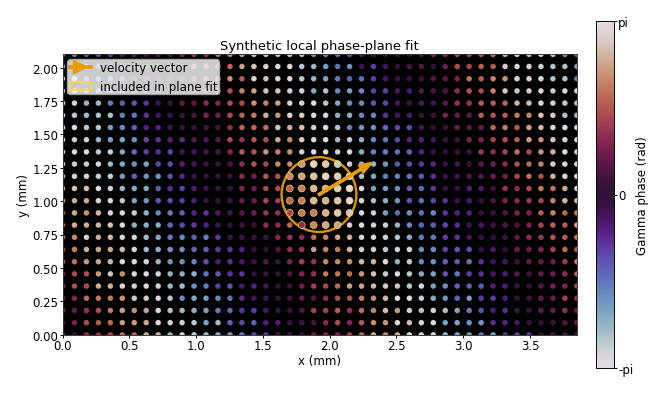

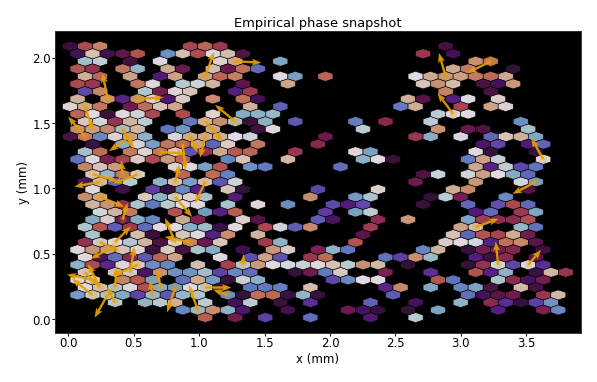

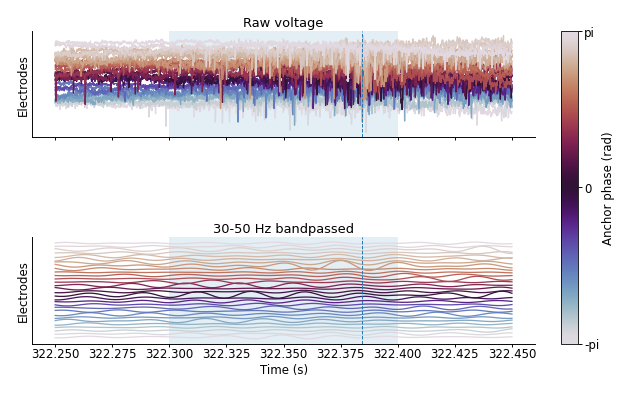

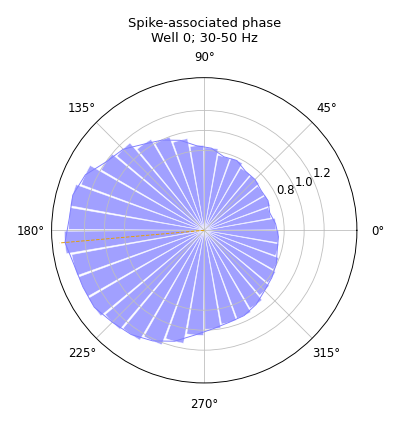

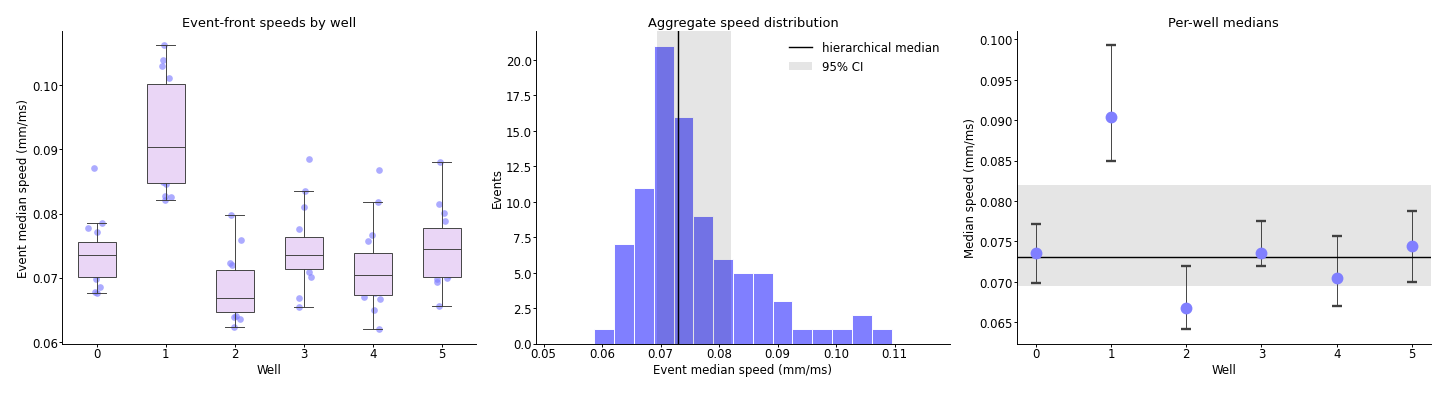

In [9]:
figure3_data = {
    "calibration_df": calibration_df,
    "calibration_summary_df": calibration_summary_df,
    "event_df": event_df,
    "local_df": local_df,
    "valid_local_df": valid_local_df,
    "event_speed_df": event_speed_df,
    "well_summary_df": well_summary_df,
    "well_bootstrap_df": well_bootstrap_df,
    "hierarchical_summary": hierarchical_summary,
    "null_corrected_event_speed_df": null_corrected_event_speed_df,
    "null_corrected_well_bootstrap_df": null_corrected_well_bootstrap_df,
    "null_corrected_hierarchical_summary": null_corrected_hierarchical_summary,
    "front_null_df": front_null_df,
    "front_significant_summary_df": front_significant_summary_df,
    "speed_panel_event_df": speed_panel_event_df,
    "speed_panel_well_bootstrap_df": speed_panel_well_bootstrap_df,
    "speed_panel_hierarchical_summary": speed_panel_hierarchical_summary,
    "speed_panel_label": SPEED_PANEL_LABEL,
    "example_well": EXAMPLE_WELL,
    "band_label": BAND_LABEL,
    "cache_note": CACHE_NOTE,
    "synthetic_plane_example": synthetic_plane_example,
    "example_trace_data": example_trace_data,
    "phase_coherence_data": phase_coherence_data,
}

fig = plt.figure(figsize=(3.8, 2.2), constrained_layout=True)
axes = synthetic_plane_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_synthetic_phase_plane_panel(figure3_data, axes)
plt.show()

fig = plt.figure(figsize=(3.4, 2.2), constrained_layout=True)
axes = snapshot_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_empirical_snapshot_panel(figure3_data, axes)
plt.show()

fig = plt.figure(figsize=(3.6, 2.2), constrained_layout=True)
axes = trace_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_example_trace_panel(figure3_data, axes)
plt.show()

fig = plt.figure(figsize=(2.6, 2.4), constrained_layout=True)
axes = phase_tuning_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_phase_tuning_panel(figure3_data, axes)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.2), constrained_layout=True)
draw_event_speed_by_well_panel(figure3_data, axes[0])
draw_speed_distribution_panel(figure3_data, axes[1])
draw_well_bootstrap_panel(figure3_data, axes[2])
plt.show()


## Compose Figure 3

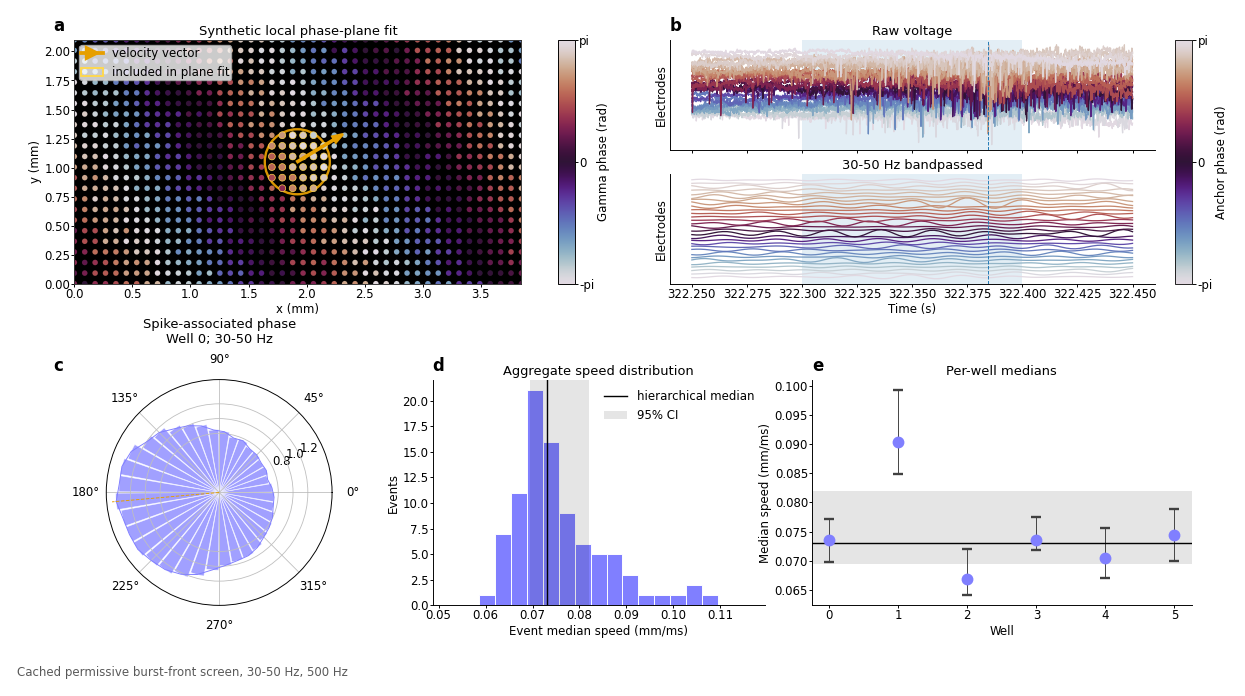

In [10]:
fig3 = compose_figure(
    figure(width="two_column", height_mm=100.0, rows=[0.54, 0.50], row_gaps=[0.065], wspace=0.0, ncols=24, constrained_layout=False),
    [
        panel(
            "synthetic_plane",
            label="a",
            loc=(0, 0, 1, 11),
            draw=draw_synthetic_phase_plane_panel,
            data=figure3_data,
            axes_factory=synthetic_plane_axes_factory,
        ),
        panel(
            "example_traces",
            label="b",
            loc=(0, 13, 1, 11),
            draw=draw_example_trace_panel,
            data=figure3_data,
            axes_factory=trace_axes_factory,
        ),
        panel(
            "phase_tuning",
            label="c",
            loc=(1, 0, 1, 7),
            draw=draw_phase_tuning_panel,
            data=figure3_data,
            axes_factory=phase_tuning_axes_factory,
        ),
        panel(
            "speed_distribution",
            label="d",
            loc=(1, 8, 1, 7),
            draw=draw_speed_distribution_panel,
            data=figure3_data,
        ),
        panel(
            "well_bootstrap",
            label="e",
            loc=(1, 16, 1, 8),
            draw=draw_well_bootstrap_panel,
            data=figure3_data,
        ),
    ],
)
fig3.fig.text(0.01, 0.01, CACHE_NOTE, ha="left", va="bottom", fontsize=FONT_SIZES["small"], color="0.35")
fig3.fig.subplots_adjust(left=0.04, right=0.985, top=0.965, bottom=0.12)
plt.show()


## Export

In [11]:
if SAVE_FIGURE:
    saved_paths = export_figure(fig3.fig, OUTPUT_DIR / "figure_3_lfp_event_front_compilation", formats=("pdf", "svg", "png"))
    print("Saved:")
    for path in saved_paths:
        print(path)

Saved:
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure3_lfp_event_front/figure_3_lfp_event_front_compilation.pdf
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure3_lfp_event_front/figure_3_lfp_event_front_compilation.svg
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure3_lfp_event_front/figure_3_lfp_event_front_compilation.png


## Data tables for reporting

In [12]:
reporting_summary = {
    "cache_note": CACHE_NOTE,
    "wells": AGGREGATE_WELLS,
    "example_well": EXAMPLE_WELL,
    "speed_panel_mode": SPEED_PANEL_MODE,
    "hierarchical_median_mm_per_s": speed_panel_hierarchical_summary["median_mm_per_s"],
    "hierarchical_ci_low_mm_per_s": speed_panel_hierarchical_summary["ci_low_mm_per_s"],
    "hierarchical_ci_high_mm_per_s": speed_panel_hierarchical_summary["ci_high_mm_per_s"],
    "n_wells": speed_panel_hierarchical_summary["n_wells"],
    "n_events": speed_panel_hierarchical_summary["n_events"],
    "n_valid_local_fits": speed_panel_hierarchical_summary["n_valid_local_fits"],
}
print(json.dumps(reporting_summary, indent=2))

table_dir = OUTPUT_DIR / "tables"
table_dir.mkdir(parents=True, exist_ok=True)
calibration_df.to_csv(table_dir / "calibration_phase_tuning.csv", index=False)
calibration_summary_df.drop(columns="config").to_csv(table_dir / "calibration_summary.csv", index=False)
event_speed_df.to_csv(table_dir / "event_speed_summary_all_qc_valid.csv", index=False)
well_bootstrap_df.drop(columns="bootstrap_samples").to_csv(table_dir / "well_bootstrap_summary_all_qc_valid.csv", index=False)
speed_panel_event_df.to_csv(table_dir / "event_speed_summary.csv", index=False)
speed_panel_well_bootstrap_df.drop(columns="bootstrap_samples").to_csv(table_dir / "well_bootstrap_summary.csv", index=False)
if not front_significant_summary_df.empty:
    front_significant_summary_df.to_csv(table_dir / "front_significant_summary.csv", index=False)
pd.DataFrame([reporting_summary]).to_csv(table_dir / "hierarchical_speed_summary.csv", index=False)
print(f"Saved reporting tables to {table_dir}")


{
  "cache_note": "Cached permissive burst-front screen, 30-50 Hz, 500 Hz",
  "wells": [
    0,
    1,
    2,
    3,
    4,
    5
  ],
  "example_well": 0,
  "hierarchical_median_mm_per_s": 73.05634713331972,
  "hierarchical_ci_low_mm_per_s": 69.44486966375435,
  "hierarchical_ci_high_mm_per_s": 82.00238610590877,
  "n_wells": 6,
  "n_events": 90,
  "n_valid_local_fits": 46098
}
Saved reporting tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure3_lfp_event_front/tables
